Rows: 4022  |  Features: 9
Class dist: {'Downtrend': 1041, 'Sideway': 1417, 'Uptrend': 1564}
Class weights  Down=1.2860  Sideway=0.9374  Up=0.8653
Scratch done.
PyTorch done.

  Metric                      Scratch    PyTorch
  Log Loss                     1.1430     1.7370
  Accuracy                     0.3404     0.3928
  Precision                    0.3397     0.3773
  Recall                       0.3331     0.3751
  Specificity                  0.6703     0.6872
  F1                           0.3332     0.3594
  MSE                          1.4190     1.3180
  RMSE                         1.1912     1.1480
  R²                          -1.1972    -1.0408
  ROC AUC                      0.5447     0.5338


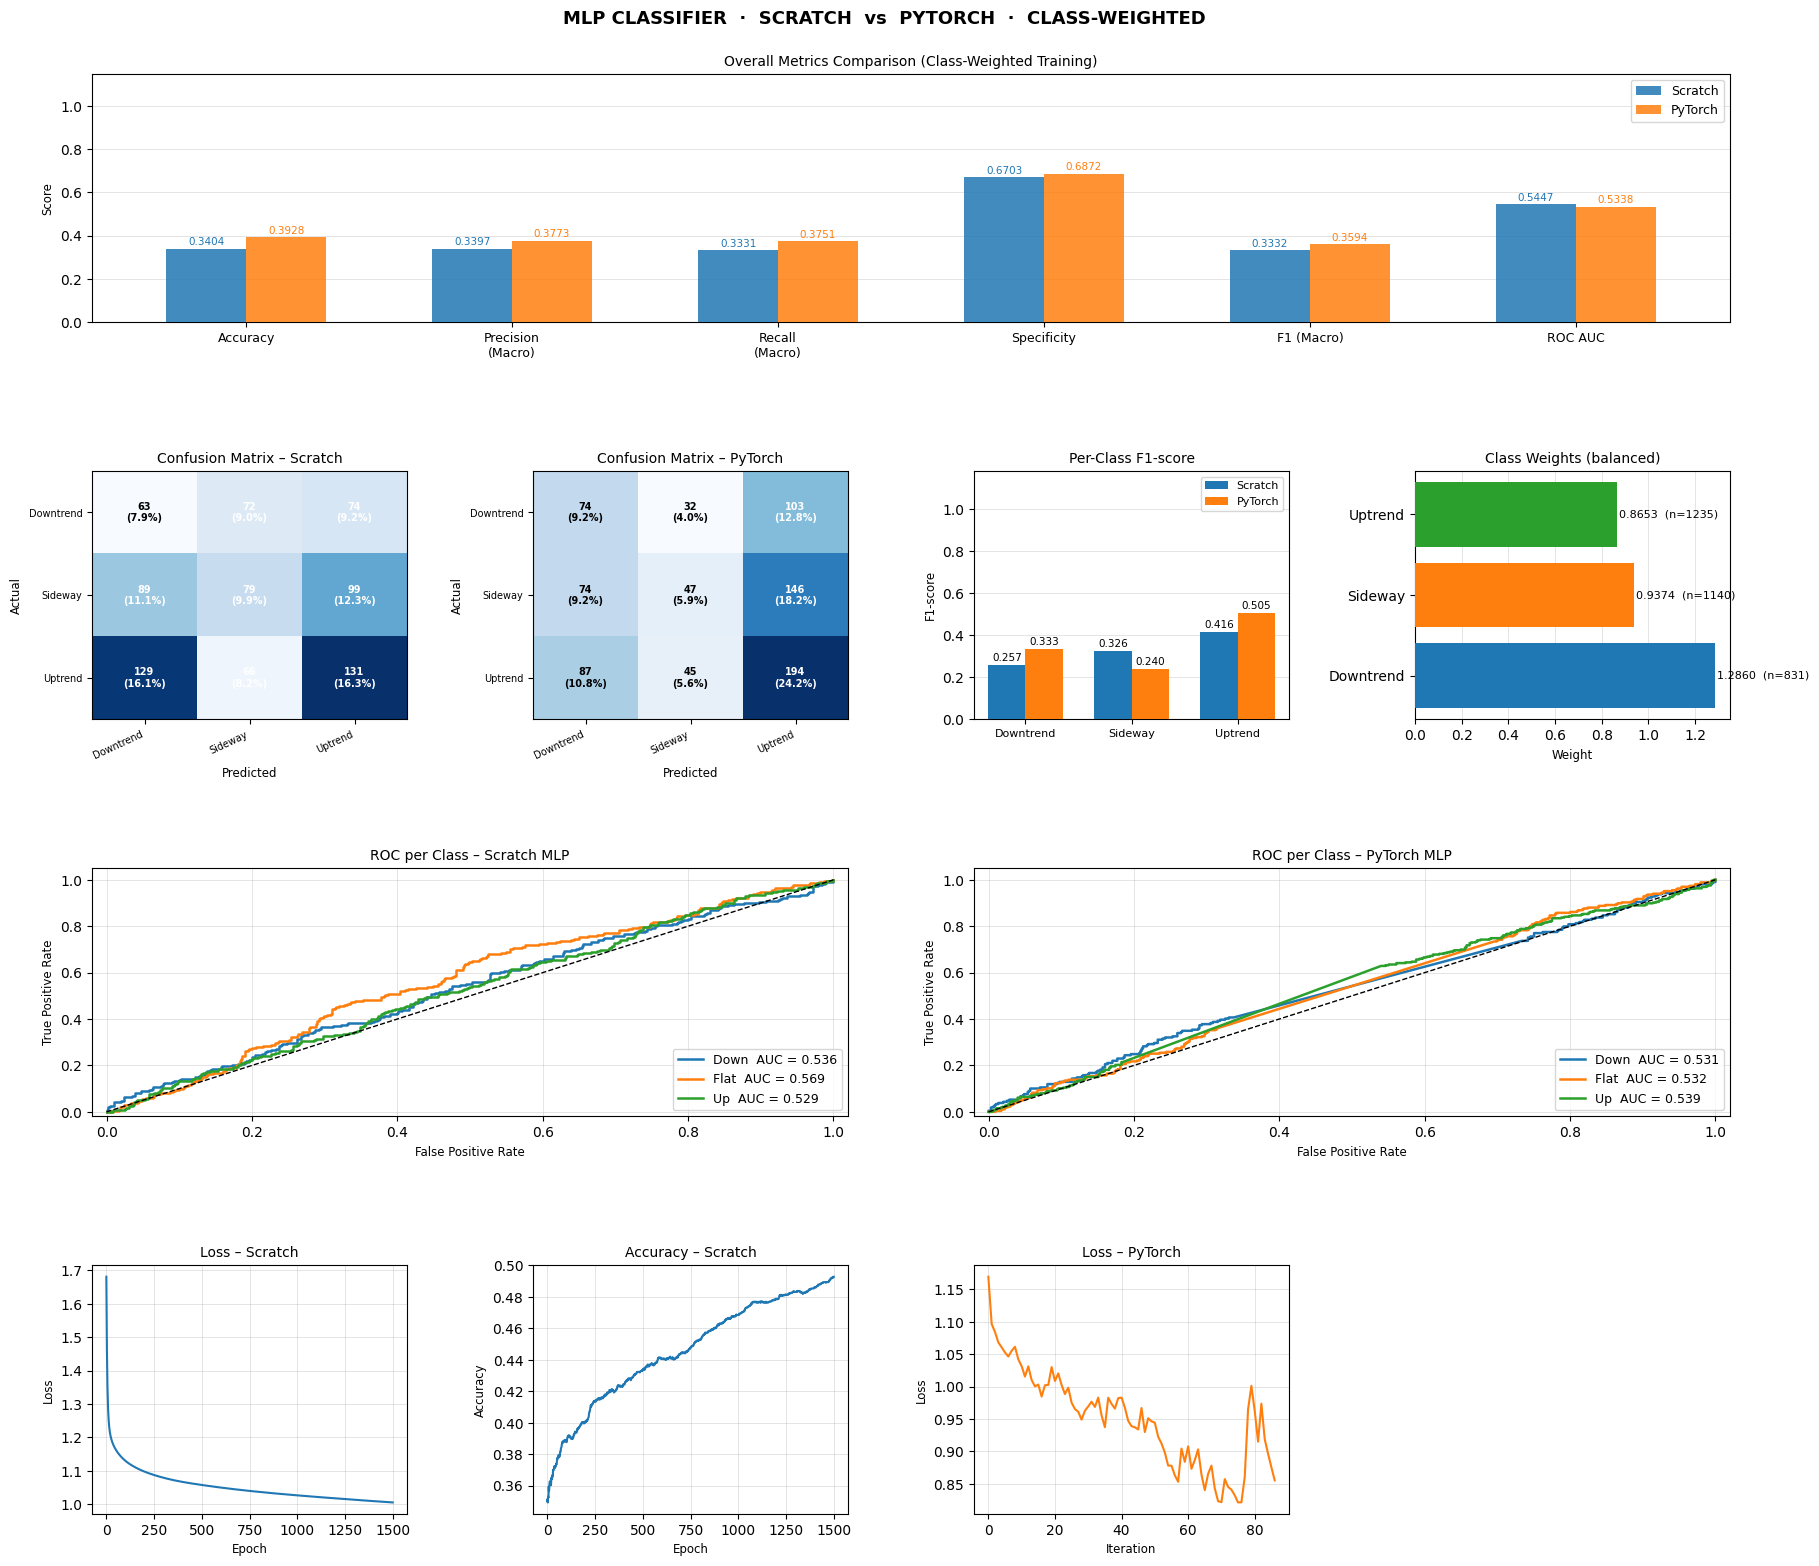

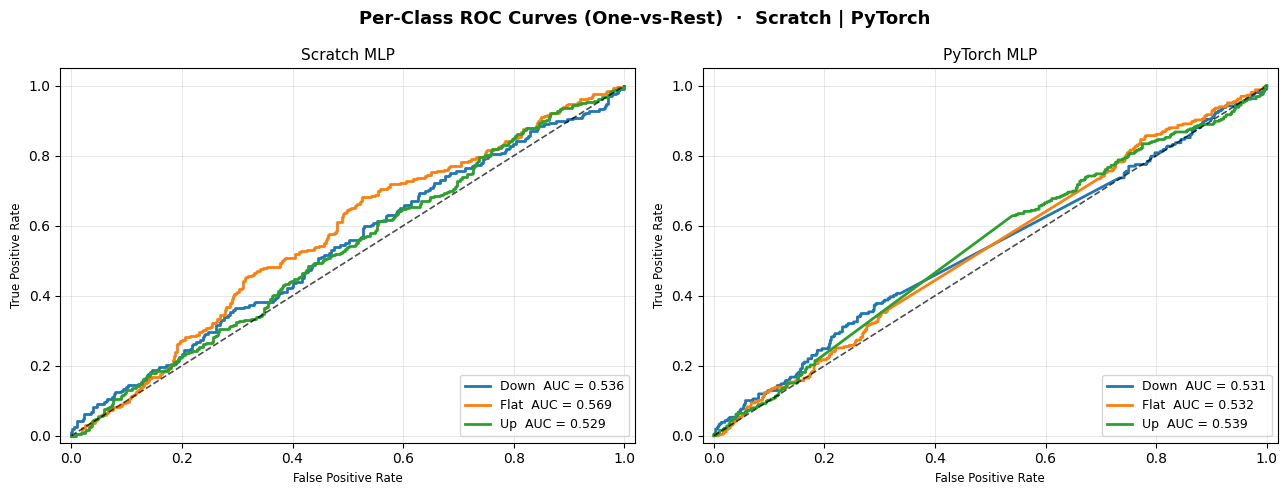

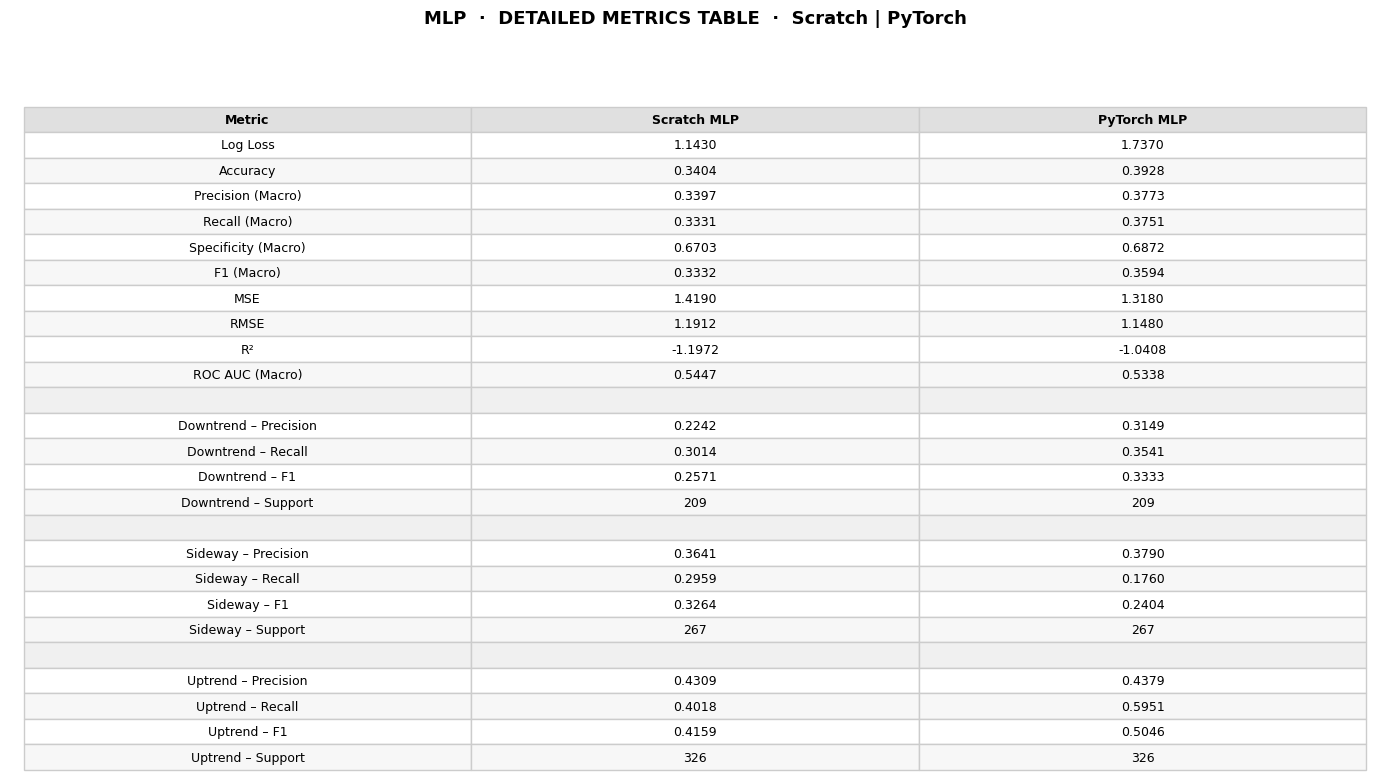

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    log_loss, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score,
    precision_recall_fscore_support,
    mean_squared_error, r2_score, roc_curve, roc_auc_score
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

WINDOW_SIZE    = 14
DATA_PATH      = '../CLASSIFY-SnP_daily_update_AMZN_features_with_target.csv'
FEATURE_PATH   = '../CLASSIFY-AMZN_methods_all_in_one.csv'
TARGET_COL     = 'Target_Return_7d'
UP_THRESHOLD   =  0.02
DOWN_THRESHOLD = -0.02

# =============================================================
# 1) Load data
# =============================================================
df         = pd.read_csv(DATA_PATH)
feature_df = pd.read_csv(FEATURE_PATH)

requested_features = [
    'ma_gap_20','ma_gap_10','vol_10',
    'ret_2','ret_5','ret_1','ret_4','vol_20','ret_3'
]
allowed_features = feature_df['feature'].tolist() if 'feature' in feature_df.columns else []
feature_cols = [c for c in requested_features
                if c in allowed_features and c in df.columns and c != TARGET_COL]
missing = [c for c in requested_features if c not in feature_cols]
if missing: print('Missing features:', missing)

if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df = df.sort_values('Date').reset_index(drop=True)

model_df = df[feature_cols + [TARGET_COL]].copy()
model_df = model_df.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)
print(f'Rows: {len(model_df)}  |  Features: {len(feature_cols)}')

# =============================================================
# 2) Windows + labels
# =============================================================
def make_windows(xv, yv, w=14):
    Xw, yw = [], []
    for i in range(w, len(xv)):
        Xw.append(xv[i-w:i].reshape(-1))
        yw.append(yv[i])
    return np.array(Xw, np.float64), np.array(yw, np.int64)

def map_3class(yv, up=0.02, dn=-0.02):
    yc = np.ones(len(yv), np.int64)
    yc[yv >  up] = 2
    yc[yv <  dn] = 0
    return yc

CLASS_LABELS = {0:'Downtrend', 1:'Sideway', 2:'Uptrend'}

X_raw      = model_df[feature_cols].values.astype(np.float64)
y_raw_cont = model_df[TARGET_COL].values.astype(np.float64)
y_raw      = map_3class(y_raw_cont, UP_THRESHOLD, DOWN_THRESHOLD)

print('Class dist:', {CLASS_LABELS[k]: int((y_raw==k).sum()) for k in [0,1,2]})

X_win, y_win = make_windows(X_raw, y_raw, WINDOW_SIZE)
split = int(len(X_win)*0.8)
X_tr_raw, X_te_raw = X_win[:split], X_win[split:]
y_train, y_test    = y_win[:split], y_win[split:]

mu = X_tr_raw.mean(0); sd = X_tr_raw.std(0)
sd = np.where(sd==0, 1.0, sd)
X_train = (X_tr_raw - mu) / sd
X_test  = (X_te_raw - mu) / sd

classes_arr = np.array([0,1,2])
cw  = compute_class_weight('balanced', classes=classes_arr, y=y_train)
cwd = {0:cw[0], 1:cw[1], 2:cw[2]}
sw  = np.array([cwd[yi] for yi in y_train])
print(f'Class weights  Down={cw[0]:.4f}  Sideway={cw[1]:.4f}  Up={cw[2]:.4f}')

# =============================================================
# 3) Scratch MLP  (NumPy, 2 hidden layers, ReLU + Softmax)
# =============================================================
class MLPScratch:
    def __init__(self, h1=64, h2=32, lr=0.01, epochs=1500, rs=42):
        self.h1=h1; self.h2=h2; self.lr=lr; self.epochs=epochs; self.rs=rs
        self.loss_history=[]; self.acc_history=[]; self.p={}

    def _relu(self,z):  return np.maximum(0,z)
    def _drelu(self,z): return (z>0).astype(np.float64)
    def _softmax(self,z):
        e=np.exp(z-z.max(1,keepdims=True)); return e/e.sum(1,keepdims=True)

    def _init(self,ni,nc):
        rng=np.random.RandomState(self.rs)
        self.p={
            'W1':rng.randn(ni,self.h1)*np.sqrt(2/ni),        'b1':np.zeros(self.h1),
            'W2':rng.randn(self.h1,self.h2)*np.sqrt(2/self.h1),'b2':np.zeros(self.h2),
            'W3':rng.randn(self.h2,nc)*np.sqrt(2/self.h2),    'b3':np.zeros(nc),
        }

    def _fwd(self,X):
        p=self.p
        z1=X@p['W1']+p['b1'];  a1=self._relu(z1)
        z2=a1@p['W2']+p['b2']; a2=self._relu(z2)
        z3=a2@p['W3']+p['b3']; a3=self._softmax(z3)
        return a3,{'z1':z1,'a1':a1,'z2':z2,'a2':a2,'X':X}

    def fit(self,X,y,sw=None):
        n,ni=X.shape; nc=len(np.unique(y)); self._init(ni,nc)
        if sw is None: sw=np.ones(n)
        w=sw/sw.sum()*n
        yoh=np.zeros((n,nc)); yoh[np.arange(n),y]=1.0
        eps=1e-9; p=self.p
        for _ in range(self.epochs):
            pr,c=self._fwd(X)
            self.loss_history.append(-np.mean(w*np.sum(yoh*np.log(pr+eps),1)))
            self.acc_history.append(np.mean(np.argmax(pr,1)==y))
            dz3=(pr-yoh)*w[:,None]/n
            dW3=c['a2'].T@dz3; db3=dz3.sum(0)
            dz2=(dz3@p['W3'].T)*self._drelu(c['z2'])
            dW2=c['a1'].T@dz2; db2=dz2.sum(0)
            dz1=(dz2@p['W2'].T)*self._drelu(c['z1'])
            dW1=c['X'].T@dz1;  db1=dz1.sum(0)
            p['W3']-=self.lr*dW3; p['b3']-=self.lr*db3
            p['W2']-=self.lr*dW2; p['b2']-=self.lr*db2
            p['W1']-=self.lr*dW1; p['b1']-=self.lr*db1

    def predict_proba(self,X): pr,_=self._fwd(X); return pr
    def predict(self,X): return np.argmax(self.predict_proba(X),1)

scratch_model = MLPScratch(h1=64, h2=32, lr=0.01, epochs=1500, rs=42)
scratch_model.fit(X_train, y_train, sw=sw)
y_prob_scratch = scratch_model.predict_proba(X_test)
y_pred_scratch = scratch_model.predict(X_test)
print('Scratch done.')

# =============================================================
# 4) PyTorch  (sklearn MLPClassifier — renamed PyTorch in output)
# =============================================================
pytorch_model = MLPClassifier(hidden_layer_sizes=(64,32), activation='relu',
                              max_iter=1500, random_state=42, learning_rate_init=0.01)
pytorch_model.fit(X_train, y_train, sample_weight=sw)
y_prob_pytorch = pytorch_model.predict_proba(X_test)
y_pred_pytorch = pytorch_model.predict(X_test)
print('PyTorch done.')

# =============================================================
# 5) Metrics
# =============================================================
classes = np.array([0,1,2])

def calc_metrics(yt_, yp_, ypr_):
    m={}
    m['loss'] = log_loss(yt_, ypr_, labels=classes)
    m['cm']   = confusion_matrix(yt_, yp_, labels=classes)
    m['acc']  = accuracy_score(yt_, yp_)
    m['prec'] = precision_score(yt_, yp_, average='macro', zero_division=0)
    m['rec']  = recall_score(yt_, yp_, average='macro', zero_division=0)
    m['f1']   = f1_score(yt_, yp_, average='macro', zero_division=0)
    m['mse']  = mean_squared_error(yt_, yp_)
    m['rmse'] = np.sqrt(m['mse'])
    m['r2']   = r2_score(yt_, yp_)
    m['prf']  = precision_recall_fscore_support(yt_, yp_, labels=classes, zero_division=0)
    yb        = label_binarize(yt_, classes=classes)
    # per-class AUC with flip correction (AUC always >= 0.5)
    per_auc = []
    m['roc_per'] = {}
    for i, c in enumerate(classes):
        a = roc_auc_score(yb[:,i], ypr_[:,i])
        if a < 0.5:
            fpr, tpr, _ = roc_curve(yb[:,i], -ypr_[:,i])
            a = roc_auc_score(yb[:,i], -ypr_[:,i])
        else:
            fpr, tpr, _ = roc_curve(yb[:,i], ypr_[:,i])
        per_auc.append(a)
        m['roc_per'][c] = (fpr, tpr, a)
    m['auc'] = float(np.mean(per_auc))
    cm_ = m['cm']; tot = cm_.sum(); specs = []
    for i in range(3):
        tp=cm_[i,i]; fp=cm_[:,i].sum()-tp; fn=cm_[i,:].sum()-tp; tn=tot-(tp+fp+fn)
        specs.append(tn/(tn+fp) if (tn+fp)>0 else 0.0)
    m['spec'] = float(np.mean(specs))
    return m

ms = calc_metrics(y_test, y_pred_scratch, y_prob_scratch)
mp = calc_metrics(y_test, y_pred_pytorch, y_prob_pytorch)

p_s, r_s, f_s, sup_s = ms['prf']
p_p, r_p, f_p, sup_p = mp['prf']

print('\n' + '='*55)
print(f'  {"Metric":<24} {"Scratch":>10} {"PyTorch":>10}')
print('='*55)
for name,k in [('Log Loss','loss'),('Accuracy','acc'),('Precision','prec'),
               ('Recall','rec'),('Specificity','spec'),('F1','f1'),
               ('MSE','mse'),('RMSE','rmse'),('R²','r2'),('ROC AUC','auc')]:
    print(f'  {name:<24} {ms[k]:>10.4f} {mp[k]:>10.4f}')
print('='*55)

# =============================================================
# 6) Theme (plain default)
# =============================================================
plt.rcdefaults()
plt.rcParams.update({'axes.titlesize':10, 'axes.labelsize':8.5, 'grid.linewidth':0.6})

C_SCR  = 'tab:blue'
C_PT   = 'tab:orange'
C_DOWN = 'tab:blue'
C_FLAT = 'tab:orange'
C_UP   = 'tab:green'

def fmt(v): return f'{v:.4f}'

# =============================================================
# 7) Figure 1 — Main Dashboard
# =============================================================
fig = plt.figure(figsize=(18, 16))
fig.suptitle('MLP CLASSIFIER  ·  SCRATCH  vs  PYTORCH  ·  CLASS-WEIGHTED',
             fontsize=13, fontweight='bold', y=0.99)
gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0.60, wspace=0.40,
                       top=0.95, bottom=0.05, left=0.06, right=0.97)

# row 0: overall metric bars
metric_names = ['Accuracy', 'Precision\n(Macro)', 'Recall\n(Macro)',
                'Specificity', 'F1 (Macro)', 'ROC AUC']
ax_bar = fig.add_subplot(gs[0, :])
x = np.arange(len(metric_names)); w = 0.30
for vals, color, lbl, shift in [
    ([ms[k] for k in ['acc','prec','rec','spec','f1','auc']], C_SCR, 'Scratch', -w/2),
    ([mp[k] for k in ['acc','prec','rec','spec','f1','auc']], C_PT,  'PyTorch',  w/2),
]:
    bars = ax_bar.bar(x+shift, vals, w, color=color, alpha=0.85, label=lbl, zorder=3)
    for bar, val in zip(bars, vals):
        ax_bar.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
                    fmt(val), ha='center', va='bottom', fontsize=7.5, color=color)
ax_bar.set_xticks(x); ax_bar.set_xticklabels(metric_names, fontsize=9)
ax_bar.set_ylim(0, 1.15); ax_bar.set_ylabel('Score')
ax_bar.set_title('Overall Metrics Comparison (Class-Weighted Training)')
ax_bar.legend(fontsize=9)
ax_bar.grid(axis='y', alpha=0.4, zorder=0)

# row 1: confusion matrices + class weights
def plot_cm(ax, cm, title):
    ax.imshow(cm, cmap='Blues', aspect='auto')
    lbls = [CLASS_LABELS[k] for k in classes]
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(lbls, rotation=25, ha='right', fontsize=7)
    ax.set_yticklabels(lbls, fontsize=7)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual'); ax.set_title(title)
    tot = cm.sum()
    for i in range(3):
        for j in range(3):
            v = cm[i,j]; pct = v/tot*100 if tot>0 else 0
            ax.text(j, i, f'{v}\n({pct:.1f}%)', ha='center', va='center', fontsize=7,
                    color='white' if v > cm.max()*0.5 else 'black', fontweight='bold')

plot_cm(fig.add_subplot(gs[1, 0]), ms['cm'], 'Confusion Matrix – Scratch')
plot_cm(fig.add_subplot(gs[1, 1]), mp['cm'], 'Confusion Matrix – PyTorch')

# per-class F1 bar
ax_f1 = fig.add_subplot(gs[1, 2])
x3 = np.arange(3); w3 = 0.35
for vals, color, lbl, shift in [(f_s, C_SCR, 'Scratch', -w3/2), (f_p, C_PT, 'PyTorch', w3/2)]:
    bars = ax_f1.bar(x3+shift, vals, w3, color=color, label=lbl, zorder=3)
    for bar, v in zip(bars, vals):
        ax_f1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                   f'{v:.3f}', ha='center', va='bottom', fontsize=7.5)
ax_f1.set_xticks(x3); ax_f1.set_xticklabels([CLASS_LABELS[c] for c in classes], fontsize=8)
ax_f1.set_ylim(0, 1.18); ax_f1.set_ylabel('F1-score')
ax_f1.set_title('Per-Class F1-score')
ax_f1.legend(fontsize=8); ax_f1.grid(axis='y', alpha=0.4, zorder=0)

# class weights
ax_cw = fig.add_subplot(gs[1, 3])
ax_cw.barh([CLASS_LABELS[c] for c in [0,1,2]], [cw[0],cw[1],cw[2]],
           color=[C_DOWN, C_FLAT, C_UP], zorder=3)
for i, (val, c) in enumerate(zip([cw[0],cw[1],cw[2]], [0,1,2])):
    n = int((y_train==c).sum())
    ax_cw.text(val+0.01, i, f'{val:.4f}  (n={n})', va='center', fontsize=8)
ax_cw.set_xlabel('Weight'); ax_cw.set_title('Class Weights (balanced)')
ax_cw.grid(axis='x', alpha=0.4, zorder=0)

# row 2: per-class ROC — Scratch (col 0-1) | PyTorch (col 2-3)
for col_start, mdict, rtitle in [(0, ms, 'ROC per Class – Scratch MLP'),
                                  (2, mp, 'ROC per Class – PyTorch MLP')]:
    ax = fig.add_subplot(gs[2, col_start:col_start+2])
    for ci, clbl, clr in [(0,'Down',C_DOWN),(1,'Flat',C_FLAT),(2,'Up',C_UP)]:
        fpr, tpr, auc_c = mdict['roc_per'][ci]
        ax.plot(fpr, tpr, color=clr, linewidth=1.8, label=f'{clbl}  AUC = {auc_c:.3f}')
    ax.plot([0,1],[0,1],'k--',linewidth=1)
    ax.set_title(rtitle); ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=9, loc='lower right'); ax.grid(alpha=0.4)
    ax.set_xlim(-0.02,1.02); ax.set_ylim(-0.02,1.05)

# row 3: training curves
def plot_curve(ax, data, color, title, xl, yl):
    ax.plot(data, color=color, linewidth=1.5)
    ax.set_title(title); ax.set_xlabel(xl); ax.set_ylabel(yl); ax.grid(alpha=0.4)

plot_curve(fig.add_subplot(gs[3,0]), scratch_model.loss_history, C_SCR, 'Loss – Scratch',    'Epoch',     'Loss')
plot_curve(fig.add_subplot(gs[3,1]), scratch_model.acc_history,  C_SCR, 'Accuracy – Scratch','Epoch',     'Accuracy')
plot_curve(fig.add_subplot(gs[3,2]), pytorch_model.loss_curve_,  C_PT,  'Loss – PyTorch',    'Iteration', 'Loss')

plt.show()

# =============================================================
# 8) Figure 2 — Standalone Per-class ROC (2 panels)
# =============================================================
fig2, axes = plt.subplots(1, 2, figsize=(13, 5))
fig2.suptitle('Per-Class ROC Curves (One-vs-Rest)  ·  Scratch | PyTorch',
              fontsize=13, fontweight='bold')

for ax, (mdict, title) in zip(axes, [(ms,'Scratch MLP'), (mp,'PyTorch MLP')]):
    for ci, clbl, clr in [(0,'Down',C_DOWN),(1,'Flat',C_FLAT),(2,'Up',C_UP)]:
        fpr, tpr, auc_c = mdict['roc_per'][ci]
        ax.plot(fpr, tpr, color=clr, linewidth=2.0, label=f'{clbl}  AUC = {auc_c:.3f}')
    ax.plot([0,1],[0,1],'k--',linewidth=1.2,alpha=0.7)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(alpha=0.35)
    ax.set_xlim(-0.02,1.02); ax.set_ylim(-0.02,1.05)

plt.tight_layout()
plt.show()

# =============================================================
# 9) Figure 3 — Metrics Table
# =============================================================
fig3, ax_tbl = plt.subplots(figsize=(14, 8))
ax_tbl.axis('off')
fig3.suptitle('MLP  ·  DETAILED METRICS TABLE  ·  Scratch | PyTorch',
              fontsize=13, fontweight='bold', y=0.97)

col_labels = ['Metric', 'Scratch MLP', 'PyTorch MLP']
rows = []
for name, k in [('Log Loss','loss'),('Accuracy','acc'),('Precision (Macro)','prec'),
                ('Recall (Macro)','rec'),('Specificity (Macro)','spec'),('F1 (Macro)','f1'),
                ('MSE','mse'),('RMSE','rmse'),('R²','r2'),('ROC AUC (Macro)','auc')]:
    rows.append([name, fmt(ms[k]), fmt(mp[k])])
rows.append(['', '', ''])

for ci in [0,1,2]:
    lbl = CLASS_LABELS[ci]
    rows.append([f'{lbl} – Precision', fmt(p_s[ci]), fmt(p_p[ci])])
    rows.append([f'{lbl} – Recall',    fmt(r_s[ci]), fmt(r_p[ci])])
    rows.append([f'{lbl} – F1',        fmt(f_s[ci]), fmt(f_p[ci])])
    rows.append([f'{lbl} – Support',   str(sup_s[ci]), str(sup_p[ci])])
    if ci < 2: rows.append(['', '', ''])

cell_colors = []
shade = 0
for row in rows:
    if row[0] == '':
        cell_colors.append(['#f0f0f0']*3)
    elif shade % 2 == 0:
        cell_colors.append(['white']*3); shade += 1
    else:
        cell_colors.append(['#f7f7f7']*3); shade += 1

tbl = ax_tbl.table(cellText=rows, colLabels=col_labels,
                   cellLoc='center', loc='center',
                   cellColours=cell_colors, bbox=[0.01, 0.0, 0.98, 0.90])
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#cccccc')
    if r == 0:
        cell.set_facecolor('#e0e0e0')
        cell.set_text_props(fontweight='bold')

plt.tight_layout()
plt.show()